# 04 — QLoRA Paper Reproduction (Llama-3-8B)

This notebook reproduces the headline results of the QLoRA paper on **Meta-Llama-3-8B** within a 2-day Colab budget. It pulls the official training script from `artidoro/qlora`, runs each experiment as a subprocess, and layers our own system-metrics logging on top.

## What we're testing

| # | Config | Claim being tested |
|---|--------|--------------------|
| 1 | NF4 + DQ, r=64, all-linear | Reference QLoRA configuration |
| 2 | FP4 + DQ, r=64, all-linear | NF4 > FP4 at 4-bit (paper Table 2) |
| 3 | NF4 no-DQ, r=64, all-linear | Double-quant is "free" (Table 4) |
| 4 | FP16 LoRA, r=64, all-linear | QLoRA matches 16-bit performance (headline claim) |
| 5 | NF4 + DQ, r=16, all-linear | Rank robustness |
| 6 | NF4 + DQ, r=8, all-linear | Rank robustness (lower) |
| 7 | NF4 + DQ, r=64, q+v only | All linear > attn-only (paper Table 9) |

## Layout

1. **Setup** — mount Drive, clone qlora repo, install pinned deps, log in to HF.
2. **Helpers** — `run_qlora_experiment` wraps subprocess + NVML polling + result aggregation.
3. **Smoke tests** — every config × 50 steps. Goal: loss decreases, no OOM, full pipeline produces a `metrics.json`.
4. **Full experiments** — one section per experiment, each preceded by a description cell stating what to expect.
5. **MMLU evaluation** — run on each saved adapter checkpoint.
6. **Aggregation** — merge into a single DataFrame and plot.

## Required Drive layout

```
MyDrive/
└── 690ab-qlora/
    └── qlora-experiment-v3/      ← this entire repo, uploaded
        ├── utils.py
        ├── configs.py
        ├── 04_qlora_paper_reproduction.ipynb
        ├── checkpoints/           ← created automatically
        ├── results/               ← created automatically
        └── logs/                  ← created automatically
```

**GPU recommendation:** A100-40GB or H100. L4-24GB works but is ~2× slower; T4 cannot fit a 7B QLoRA run.

## 1. Setup

Mount Drive, clone the qlora repo at a pinned commit, install dependencies, log in to Hugging Face (Llama-3 is gated).

In [1]:
%pip install -q -U \
 torch==2.10.0 \
 torchvision==0.25.0 \
 torchaudio==2.10.0 \
 transformers==4.44.2 \
 peft==0.12.0 \
 accelerate==0.34.2 \
 bitsandbytes>=0.45.0 \
 datasets==2.21.0 \
 sentencepiece scipy einops evaluate pynvml tqdm

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


In [2]:
# Mount Drive and define paths
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os, sys

PROJECT_ROOT = Path('/content/drive/MyDrive/690ab-qlora/qlora-experiment-v3')
QLORA_DIR    = Path('/content/qlora')                       # cloned repo (ephemeral)
RESULTS_DIR  = PROJECT_ROOT / 'results'
CHECKPOINTS_DIR = PROJECT_ROOT / 'checkpoints'
LOG_DIR      = PROJECT_ROOT / 'logs'

for d in (RESULTS_DIR, CHECKPOINTS_DIR, LOG_DIR):
    d.mkdir(parents=True, exist_ok=True)

assert PROJECT_ROOT.exists(), f'Project root not found at {PROJECT_ROOT}. Upload the repo to Drive first.'
sys.path.insert(0, str(PROJECT_ROOT))
print('Project root:', PROJECT_ROOT)

Mounted at /content/drive
Project root: /content/drive/MyDrive/690ab-qlora/qlora-experiment-v3


In [3]:
# Clone qlora repo at a known-good commit, then patch find_all_linear_names
# to support a comma-separated env override. We need this for the q+v-only
# ablation (qlora.py auto-targets all linears by default).
import subprocess
import shutil # Import shutil for rmtree

QLORA_COMMIT = '7f4e95a68dc076bea9b3a413d2b512eca6d004e5'  # main as of 2024-01; pin for reproducibility

# Ensure a clean state by removing the directory if it exists
if QLORA_DIR.exists():
    print(f"Removing existing QLORA_DIR: {QLORA_DIR}")
    shutil.rmtree(QLORA_DIR)

# Now, clone and checkout
subprocess.check_call(['git', 'clone', 'https://github.com/artidoro/qlora.git', str(QLORA_DIR)])
subprocess.check_call(['git', '-C', str(QLORA_DIR), 'checkout', QLORA_COMMIT])

# Patch1: allow QLORA_TARGET_MODULES env var to override module discovery.
qlora_py = QLORA_DIR / 'qlora.py'
src = qlora_py.read_text()
marker = '# === target_modules env override ==='
if marker not in src:
    src = src.replace(
        'def find_all_linear_names(args, model):',
        ('def find_all_linear_names(args, model):\n'
         f'    {marker}\n'
         '    import os as _os_pat\n'
         '    _ovr = _os_pat.environ.get("QLORA_TARGET_MODULES")\n'
         '    if _ovr:\n'
         '        return [m.strip() for m in _ovr.split(",")]'),
    )
    qlora_py.write_text(src)
    print('Patched qlora.py with target_modules env override.')
else:
    print('qlora.py already patched.')

Patched qlora.py with target_modules env override.


In [4]:
# Comprehensive qlora.py patch v4 — adds Patch E (Llama-3 has no unk_token).
# Replaces the previous v3 cell. Idempotent.
import subprocess, re, ast
from pathlib import Path

qlora_py = QLORA_DIR / 'qlora.py'

# (0) Reset.
subprocess.check_call(['git', '-C', str(QLORA_DIR), 'checkout', '--', 'qlora.py'])
src = qlora_py.read_text()

# (A) target_modules env override.
markerA = '# === target_modules env override ==='
src = src.replace(
    'def find_all_linear_names(args, model):',
    ('def find_all_linear_names(args, model):\n'
     f'    {markerA}\n'
     '    import os as _os_pat\n'
     '    _ovr = _os_pat.environ.get("QLORA_TARGET_MODULES")\n'
     '    if _ovr:\n'
     '        return [m.strip() for m in _ovr.split(",")]'),
)

# (B) Drop redundant load_in_4bit / load_in_8bit kwargs.
markerB = '# === load_in_4bit kwarg removed ==='
bad_b = (
    "        load_in_4bit=args.bits == 4,\n"
    "        load_in_8bit=args.bits == 8,\n"
    "        device_map=device_map,\n"
    "        max_memory=max_memory,\n"
    "        quantization_config=BitsAndBytesConfig("
)
good_b = (
    "        device_map=device_map,\n"
    "        max_memory=max_memory,\n"
    f"        {markerB}\n"
    "        quantization_config=BitsAndBytesConfig("
)
assert bad_b in src, '(B) load_in_4bit block not found.'
src = src.replace(bad_b, good_b)

# (C) use_auth_token=args.use_auth_token → token=True
src, n_c = re.subn(
    r'use_auth_token\s*=\s*args\.use_auth_token,?',
    'token=True,  # === token=True forced for gated repos ===',
    src,
)

# (D) Llama-3 fast tokenizer (tolerant version).
src, n_d1 = re.subn(r'\buse_fast\s*=\s*False\b', 'use_fast=True', src)
src, n_d2 = re.subn(
    r"\n[ \t]*tokenizer_type\s*=\s*['\"]llama['\"]\s+if\s+['\"]llama['\"]\s+in\s+args\.model_name_or_path\s+else\s+None\s*,?",
    '',
    src,
)

# (E) NEW: Llama-3 has no <unk> token. Remove the unk_token entry from
# add_special_tokens — it crashes when pad_token_id is None and would be
# semantically wrong even if it didn't.
markerE = '# === unk_token entry removed for Llama-3 ==='
new_src, n_e = re.subn(
    r'\n[ \t]*"unk_token":\s*tokenizer\.convert_ids_to_tokens\(.*?\)\s*,?',
    f'\n            {markerE}',
    src,
    flags=re.DOTALL,
)
if n_e == 0:
    print('WARNING: Patch E matched nothing. unk_token-related lines:')
    for i, line in enumerate(src.splitlines(), 1):
        if 'unk_token' in line:
            print(f'  {i}: {line}')
else:
    src = new_src

# Sanity.
remaining_auth = src.count('args.use_auth_token')
qlora_py.write_text(src)
ast.parse(src)

print(f'Patched: target_modules + load_in_4bit + {n_c} auth + Patch D ({n_d1} use_fast, {n_d2} tok_type) + Patch E ({n_e} unk_token).')
print(f'Remaining args.use_auth_token: {remaining_auth} (must be 0).')
print('Syntax check: OK.')


Patched: target_modules + load_in_4bit + 2 auth + Patch D (1 use_fast, 1 tok_type) + Patch E (1 unk_token).
Remaining args.use_auth_token: 0 (must be 0).
Syntax check: OK.


In [6]:
!grep -n -E 'AutoTokenizer|use_fast|tokenizer_type' /content/qlora/qlora.py


26:    AutoTokenizer,
351:    tokenizer = AutoTokenizer.from_pretrained(
355:        use_fast=True, # Fast tokenizer giving issues. # Needed for HF name change


In [5]:
# --- HF authentication: works in both notebook + subprocess contexts ---
import os, torch
from huggingface_hub import login, HfFolder, hf_hub_download

# Resolve token from (in order): Colab Secrets, existing env var, on-disk cache, interactive prompt.
hf_token = None
try:
    from google.colab import userdata
    hf_token = userdata.get('HF_TOKEN')           # set once in Colab's Secrets sidebar (key icon, left)
except Exception:
    pass
if not hf_token:
    hf_token = os.environ.get('HF_TOKEN') or HfFolder.get_token()
if not hf_token:
    login()                                       # interactive fallback
    hf_token = HfFolder.get_token()

assert hf_token, 'No HF token resolved. Set it in Colab Secrets as HF_TOKEN, or run login() manually.'

# Make it visible to BOTH this kernel AND any child subprocess (qlora.py).
os.environ['HF_TOKEN'] = hf_token
os.environ['HUGGING_FACE_HUB_TOKEN'] = hf_token   # older libs read this name
login(token=hf_token, add_to_git_credential=False)

# Verify access NOW, in this process — fail loud here, not inside a 30-min subprocess.
hf_hub_download('meta-llama/Meta-Llama-3-8B', 'config.json', token=hf_token)
print('HF auth OK — config.json fetched for Meta-Llama-3-8B.')

# GPU sanity (unchanged from before)
assert torch.cuda.is_available(), 'No GPU detected. Runtime → Change runtime type → GPU.'
print('GPU:', torch.cuda.get_device_name(0))
print('VRAM (GB):', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))

import utils
print('Utils loaded from:', utils.__file__)


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

HF auth OK — config.json fetched for Meta-Llama-3-8B.
GPU: NVIDIA H100 80GB HBM3
VRAM (GB): 85.0
Utils loaded from: /content/drive/MyDrive/690ab-qlora/qlora-experiment-v3/utils.py


## 2. Common configuration + experiment runner

`run_qlora_experiment` does three things in one call:

1. Builds a CLI invocation of `qlora.py` with the experiment-specific args merged into a fixed common base (model, dataset, optimizer, eval cadence).
2. Spawns a background NVML poller that records VRAM and GPU-util every 5s for the lifetime of the subprocess.
3. After the run completes, merges the poller output with `trainer_state.json` (loss curves, eval losses) into a single `<exp>_metrics.json` under `results/`.

Subprocess (rather than importing qlora.train) is intentional: it isolates CUDA contexts so a crash in one experiment doesn't poison the notebook kernel.

In [6]:
MODEL_NAME = 'meta-llama/Meta-Llama-3-8B'
DATASET    = 'alpaca'                    # 52k instruction-response pairs
MAX_TRAIN_SAMPLES = 20000                # subsample for time budget; bump to 52000 if slack remains

COMMON_ARGS = {
    'model_name_or_path':            MODEL_NAME,
    'dataset':                       DATASET,
    'max_train_samples':             MAX_TRAIN_SAMPLES,
    'source_max_len':                384,
    'target_max_len':                128,
    'per_device_train_batch_size':   1,
    'per_device_eval_batch_size':    1,
    'gradient_accumulation_steps':   16,   # effective batch 16
    'learning_rate':                 2e-4,
    'lr_scheduler_type':             'cosine',
    'warmup_ratio':                  0.03,
    'weight_decay':                  0.0,
    'max_grad_norm':                 0.3,
    'optim':                         'paged_adamw_32bit',
    'gradient_checkpointing':        True,
    'bf16':                          True,
    'logging_steps':                 10,
    'save_strategy':                 'steps',
    'save_steps':                    500,
    'save_total_limit':              1,
    'evaluation_strategy':           'steps',
    'eval_steps':                    250,
    'do_train':                      True,
    'do_eval':                       True,
    'do_mmlu_eval':                  False,   # we'll run MMLU separately at the end
    'report_to':                     'none',
    'ddp_find_unused_parameters':    False,
    'seed':                          42,
}

In [7]:
COMMON_ARGS.update({
    'per_device_train_batch_size':   4,        # was 1 — H100 has the memory
    'per_device_eval_batch_size':    8,        # was 1 — eval is forward-only, can go wider
    'gradient_accumulation_steps':   4,        # was 16 — effective batch unchanged at 16
    'gradient_checkpointing':        False,    # was True — H100 doesn't need it for NF4
    'eval_steps':                    500,      # was 250 — half the eval overhead
    'save_steps':                    500,
    'logging_steps':                 20,
})

MAX_TRAIN_SAMPLES = 8000                       # was 20000 — keeps signal, cuts cost
COMMON_ARGS['max_train_samples'] = MAX_TRAIN_SAMPLES
COMMON_ARGS['num_train_epochs']  = 2           # was 3


In [22]:
import json, time, threading, subprocess
from pathlib import Path

def _build_cmd(args: dict, output_dir: Path, smoke: bool):
    a = dict(COMMON_ARGS)
    a.update(args)
    a['output_dir'] = str(output_dir)
    if smoke:
        a.update({
            'max_steps':       50,
            'eval_steps':      25,
            'save_steps':      50,
            'logging_steps':   5,
        })
        a.pop('num_train_epochs', None)
    # else:
    #     a['num_train_epochs'] = 3
        # a.pop('max_steps', None)

    cmd = ['python', str(QLORA_DIR / 'qlora.py')]
    for k, v in a.items():
        if isinstance(v, bool):
            if v:
                cmd.append(f'--{k}')
        else:
            cmd += [f'--{k}', str(v)]
    return cmd

def _start_nvml_poller(stop_evt, samples, peak_box):
    import pynvml
    pynvml.nvmlInit()
    h = pynvml.nvmlDeviceGetHandleByIndex(0)
    while not stop_evt.is_set():
        mem = pynvml.nvmlDeviceGetMemoryInfo(h)
        util = pynvml.nvmlDeviceGetUtilizationRates(h)
        used_mb = mem.used / 1e6
        peak_box[0] = max(peak_box[0], used_mb)
        samples.append({'t': time.time(), 'vram_mb': round(used_mb, 1), 'gpu_util': util.gpu})
        time.sleep(5)

def run_qlora_experiment(name: str, exp_args: dict, smoke: bool = False, target_modules: str | None = None):
    """Run one qlora.py invocation. Logs system metrics, parses trainer_state.json."""
    suffix = '_smoke' if smoke else ''
    output_dir = CHECKPOINTS_DIR / f'{name}{suffix}'
    output_dir.mkdir(parents=True, exist_ok=True)
    log_file = LOG_DIR / f'{name}{suffix}.log'
    metrics_file = RESULTS_DIR / f'{name}{suffix}_metrics.json'

    cmd = _build_cmd(exp_args, output_dir, smoke=smoke)
    env = os.environ.copy()
    if target_modules:
        env['QLORA_TARGET_MODULES'] = target_modules

    samples, peak_box, stop_evt = [], [0.0], threading.Event()
    poller = threading.Thread(target=_start_nvml_poller, args=(stop_evt, samples, peak_box), daemon=True)
    poller.start()

    print(f'\n>>> Running {name}{suffix}  (smoke={smoke})  →  {output_dir}')
    print('    log:', log_file)
    import shlex

    t0 = time.time()
    with open(log_file, 'w') as fh:
        cmd_str = ' '.join(shlex.quote(c) for c in cmd) + f' 2>&1 | tee {shlex.quote(str(log_file))}'
        proc = subprocess.run(['bash', '-c', cmd_str], env=env)
        # proc = subprocess.run(cmd, stdout=fh, stderr=subprocess.STDOUT, env=env)
    elapsed = time.time() - t0
    stop_evt.set(); poller.join(timeout=10)

    metrics = {
        'experiment':    name,
        'smoke':         smoke,
        'wall_clock_s':  round(elapsed, 1),
        'return_code':   proc.returncode,
        'peak_vram_mb':  round(peak_box[0], 1),
        'gpu_name':      torch.cuda.get_device_name(0),
        'args':          exp_args,
        'target_modules_override': target_modules,
        'nvml_samples':  samples,
    }
    ts = output_dir / 'trainer_state.json'
    if ts.exists():
        with open(ts) as f:
            tsd = json.load(f)
        metrics['log_history'] = tsd.get('log_history', [])
        metrics['best_metric'] = tsd.get('best_metric')
    else:
        metrics['log_history'] = []
    with open(metrics_file, 'w') as f:
        json.dump(metrics, f, indent=2)

    status = 'OK' if proc.returncode == 0 else f'FAILED (rc={proc.returncode})'
    print(f'<<< {name}{suffix}  {status}  |  {elapsed/60:.1f} min  |  peak VRAM {metrics["peak_vram_mb"]:.0f} MB')
    return metrics

In [9]:
def verify_run(name: str, suffix: str = ''):
    """Quick post-run health check. Prints rc, loss trajectory, peak VRAM with verdicts."""
    import json
    from pathlib import Path

    # Expected peak VRAM bands for Llama-3-8B with COMMON_ARGS (batch=1, grad_accum=16, seq=512).
    # Tune if your settings differ; values are rough — flag outside, don't fail outright.
    expected_vram_gb = {
        # 4-bit configs: weights ≈ 5 GB; rest is activations + LoRA + optimizer state
        '01_nf4_dq_r64_all':   (7,  12),
        '02_fp4_dq_r64_all':   (7,  12),
        '03_nf4_nodq_r64_all': (8,  13),   # +0.4 bits/param vs DQ
        '04_fp16_lora_r64_all':(15, 22),   # 16-bit weights ≈ 16 GB
        '05_nf4_dq_r16_all':   (7,  12),
        '06_nf4_dq_r8_all':    (7,  11),
        '07_nf4_dq_r64_qv':    (7,  11),
    }

    p = RESULTS_DIR / f'{name}{suffix}_metrics.json'
    if not p.exists():
        print(f'[FAIL] No metrics file at {p}'); return
    with open(p) as f:
        m = json.load(f)

    # 1. Return code
    rc = m.get('return_code')
    rc_ok = rc == 0
    print(f'  return_code        : {rc}  {"OK" if rc_ok else "FAIL"}')

    # 2. Loss trajectory
    losses = [e['loss'] for e in m.get('log_history', []) if 'loss' in e]
    eval_losses = [e['eval_loss'] for e in m.get('log_history', []) if 'eval_loss' in e]
    if losses:
        first, last = losses[0], losses[-1]
        loss_ok = last < first
        print(f'  train loss         : {first:.4f} → {last:.4f}   '
              f'(min {min(losses):.4f})  {"OK" if loss_ok else "WARN: did not drop"}')
    else:
        loss_ok = False
        print('  train loss         : (none logged)  FAIL')
    if eval_losses:
        print(f'  eval  loss         : {eval_losses[0]:.4f} → {eval_losses[-1]:.4f}   '
              f'(final {eval_losses[-1]:.4f})')

    # 3. Peak VRAM in expected range
    peak_gb = m.get('peak_vram_mb', 0) / 1024
    lo, hi = expected_vram_gb.get(name, (0, 999))
    vram_ok = lo <= peak_gb <= hi
    verdict = 'OK' if vram_ok else f'WARN: outside expected [{lo}-{hi}] GB'
    print(f'  peak VRAM          : {peak_gb:.1f} GB        {verdict}')

    # 4. Throughput sanity
    util_samples = [s.get('gpu_util', 0) for s in m.get('nvml_samples', [])]
    if util_samples:
        mean_util = sum(util_samples) / len(util_samples)
        print(f'  mean GPU util      : {mean_util:.0f}%   '
              f'{"OK" if mean_util > 60 else "WARN: low — runs may be I/O bound"}')

    # 5. Wall clock
    wall_min = m.get('wall_clock_s', 0) / 60
    print(f'  wall clock         : {wall_min:.1f} min  ({m.get("gpu_name", "?")})')

    overall = rc_ok and loss_ok and vram_ok
    print(f'\n  OVERALL            : {"PASS" if overall else "INVESTIGATE"}')
    return overall


## 3. Experiment matrix

In [12]:
# EXPERIMENTS = {
#     # --- Tier 1: NF4 vs FP4 vs no-DQ vs FP16 (the headline reproductions) ---
#     '01_nf4_dq_r64_all':   {'args': {'bits': 4,  'quant_type': 'nf4', 'double_quant': True,  'lora_r': 64, 'lora_alpha': 16}, 'target_modules': None},
#     '02_fp4_dq_r64_all':   {'args': {'bits': 4,  'quant_type': 'fp4', 'double_quant': True,  'lora_r': 64, 'lora_alpha': 16}, 'target_modules': None},
#     '03_nf4_nodq_r64_all': {'args': {'bits': 4,  'quant_type': 'nf4', 'double_quant': False, 'lora_r': 64, 'lora_alpha': 16}, 'target_modules': None},
#     '04_fp16_lora_r64_all':{'args': {'bits': 16, 'lora_r': 64, 'lora_alpha': 16},                                              'target_modules': None},
#     # --- Tier 2: rank ablation, target-module ablation ---
#     '05_nf4_dq_r16_all':   {'args': {'bits': 4,  'quant_type': 'nf4', 'double_quant': True,  'lora_r': 16, 'lora_alpha': 16}, 'target_modules': None},
#     '06_nf4_dq_r8_all':    {'args': {'bits': 4,  'quant_type': 'nf4', 'double_quant': True,  'lora_r': 8,  'lora_alpha': 16}, 'target_modules': None},
#     '07_nf4_dq_r64_qv':    {'args': {'bits': 4,  'quant_type': 'nf4', 'double_quant': True,  'lora_r': 64, 'lora_alpha': 16}, 'target_modules': 'q_proj,v_proj'},
# }
EXPERIMENTS = {
    # Anchor — QLoRA reference config
    '01_nf4_dq_r64_all':    {'args': {'bits': 4,  'quant_type': 'nf4', 'double_quant': True, 'lora_r': 64, 'lora_alpha': 16}, 'target_modules': None},
    # NF4 > FP4 (paper's central novelty — the NF4 datatype)
    '02_fp4_dq_r64_all':    {'args': {'bits': 4,  'quant_type': 'fp4', 'double_quant': True, 'lora_r': 64, 'lora_alpha': 16}, 'target_modules': None},
    # 16-bit baseline (paper's headline "QLoRA matches FP16" claim)
    '04_fp16_lora_r64_all': {'args': {'bits': 16, 'lora_r': 64, 'lora_alpha': 16},                                              'target_modules': None},
}


for k in EXPERIMENTS:
    print(f'  {k}')

  01_nf4_dq_r64_all
  02_fp4_dq_r64_all
  04_fp16_lora_r64_all


## 4. Smoke testing

**What this stage tries to prove, before we burn 24 hours on full runs:**

- The whole pipeline runs end-to-end for every config: data loads, LoRA attaches, optimizer steps, eval runs, checkpoint saves, `trainer_state.json` is written.
- The training **loss decreases** over the first ~50 steps. If it stays flat or NaNs, something is wrong (bad learning rate, bad target modules, NaN in 4-bit dequant, etc.).
- **No OOM** at the configured `per_device_train_batch_size × gradient_accumulation_steps`. If smoke OOMs, the full run will too — fix it now.
- The system-metrics poller produces sensible peak-VRAM numbers per config. Expect roughly: NF4-r64 ≈ 8-10 GB, NF4-r8 ≈ 7-8 GB, FP16 LoRA ≈ 18-20 GB on Llama-3-8B.

Each smoke run is `max_steps=50`, `eval_steps=25`. Total ≈ 25-40 minutes for all 7 on an A100.

**What we do NOT learn from smoke tests:** final quality (50 steps is too few), real throughput steady-state (warmup dominates), or whether MMLU eval works (we run that separately).

In [39]:
# Run every config in smoke mode. Failures are surfaced but don't stop the loop.
smoke_results = {}
for name, spec in EXPERIMENTS.items():
    try:
        smoke_results[name] = run_qlora_experiment(
            name, spec['args'], smoke=True, target_modules=spec['target_modules'],
        )
    except Exception as e:
        print(f'!!! {name} crashed in driver: {e}')
        smoke_results[name] = {'experiment': name, 'crashed': str(e)}


>>> Running 01_nf4_dq_r64_all_smoke  (smoke=True)  →  /content/drive/MyDrive/690ab-qlora/qlora-experiment-v3/checkpoints/01_nf4_dq_r64_all_smoke
    log: /content/drive/MyDrive/690ab-qlora/qlora-experiment-v3/logs/01_nf4_dq_r64_all_smoke.log
<<< 01_nf4_dq_r64_all_smoke  OK  |  17.7 min  |  peak VRAM 13070 MB

>>> Running 02_fp4_dq_r64_all_smoke  (smoke=True)  →  /content/drive/MyDrive/690ab-qlora/qlora-experiment-v3/checkpoints/02_fp4_dq_r64_all_smoke
    log: /content/drive/MyDrive/690ab-qlora/qlora-experiment-v3/logs/02_fp4_dq_r64_all_smoke.log
<<< 02_fp4_dq_r64_all_smoke  OK  |  17.6 min  |  peak VRAM 13104 MB

>>> Running 03_nf4_nodq_r64_all_smoke  (smoke=True)  →  /content/drive/MyDrive/690ab-qlora/qlora-experiment-v3/checkpoints/03_nf4_nodq_r64_all_smoke
    log: /content/drive/MyDrive/690ab-qlora/qlora-experiment-v3/logs/03_nf4_nodq_r64_all_smoke.log
<<< 03_nf4_nodq_r64_all_smoke  OK  |  18.6 min  |  peak VRAM 13137 MB

>>> Running 04_fp16_lora_r64_all_smoke  (smoke=True)  →  /

In [40]:
# Validate smoke results: did the loss go down and did each run finish cleanly?
import pandas as pd

rows = []
for name, m in smoke_results.items():
    losses = [e['loss'] for e in m.get('log_history', []) if 'loss' in e]
    first_loss = losses[0] if losses else None
    last_loss  = losses[-1] if losses else None
    decreased  = (first_loss is not None and last_loss is not None and last_loss < first_loss)
    rows.append({
        'experiment':    name,
        'rc':            m.get('return_code'),
        'wall_min':      round(m.get('wall_clock_s', 0)/60, 1),
        'peak_vram_mb':  m.get('peak_vram_mb'),
        'first_loss':    round(first_loss, 4) if first_loss else None,
        'last_loss':     round(last_loss, 4)  if last_loss else None,
        'loss_dropped':  decreased,
    })
smoke_df = pd.DataFrame(rows)
print(smoke_df.to_string(index=False))

bad = smoke_df[(smoke_df['rc'] != 0) | (~smoke_df['loss_dropped'])]
if len(bad) > 0:
    print('\n!!! Investigate before launching full runs:\n', bad.to_string(index=False))
else:
    print('\nAll smoke runs OK — safe to proceed to full experiments.')

          experiment  rc  wall_min  peak_vram_mb  first_loss  last_loss  loss_dropped
   01_nf4_dq_r64_all   0      17.7       13070.0      1.5230     1.3212          True
   02_fp4_dq_r64_all   0      17.6       13103.6      1.5493     1.3218          True
 03_nf4_nodq_r64_all   0      18.6       13137.1      1.5228     1.3106          True
04_fp16_lora_r64_all   0      18.1       13036.5      1.5233     1.2995          True
   05_nf4_dq_r16_all   0      18.2       12478.6      1.5227     1.2990          True
    06_nf4_dq_r8_all   0      17.6        8326.3      1.5224     1.3490          True
    07_nf4_dq_r64_qv   0      14.0        8336.8      1.5551     1.4006          True

All smoke runs OK — safe to proceed to full experiments.


## 5. Full experiments

Each experiment below has its own description cell stating **what we're testing and what the QLoRA paper led us to expect**, followed by a code cell that launches the full 3-epoch run.

**Recommended ordering**: run Tier 1 (Exp 1-4) on Day 1 evening, then Tier 2 (Exp 5-7) on Day 2. The 16-bit baseline (Exp 4) is the slowest and most likely to OOM — run it first while you can still react.

**If a run will exceed its time budget by >30%**: kill it, drop `num_train_epochs` to 2 in `COMMON_ARGS`, restart. Don't let one slow run starve the matrix.

### Experiment 1 — NF4 + Double-Quant, r=64, all linear modules

**This is the reference QLoRA configuration.** All other 4-bit experiments are perturbations of this one.

**Paper expectation:**
- Quality (Alpaca eval loss / MMLU) within ~1 point of the FP16 LoRA baseline (Exp 4).
- Lowest peak VRAM of any LoRA config in this matrix (~8-10 GB on Llama-3-8B with seq_len 512, batch 1, grad-accum 16).
- Throughput somewhat lower than FP16 LoRA per step due to dequantization on every forward, but **enabled batch sizes / sequence lengths that FP16 cannot fit** is the real win — not relevant at our small batch size, but visible in peak VRAM.

In [23]:
COMMON_ARGS['max_steps'] = -1
COMMON_ARGS['max_steps'] = 1000
COMMON_ARGS['num_train_epochs']   = 2

In [24]:
cmd = _build_cmd(EXPERIMENTS['01_nf4_dq_r64_all']['args'],
                 CHECKPOINTS_DIR / '01_nf4_dq_r64_all',
                 smoke=False)
print(' '.join(cmd))


python /content/qlora/qlora.py --model_name_or_path meta-llama/Meta-Llama-3-8B --dataset alpaca --max_train_samples 8000 --source_max_len 384 --target_max_len 128 --per_device_train_batch_size 4 --per_device_eval_batch_size 8 --gradient_accumulation_steps 4 --learning_rate 0.0002 --lr_scheduler_type cosine --warmup_ratio 0.03 --weight_decay 0.0 --max_grad_norm 0.3 --optim paged_adamw_32bit --bf16 --logging_steps 20 --save_strategy steps --save_steps 500 --save_total_limit 1 --evaluation_strategy steps --eval_steps 500 --do_train --do_eval --report_to none --seed 42 --num_train_epochs 2 --max_steps 1000 --bits 4 --quant_type nf4 --double_quant --lora_r 64 --lora_alpha 16 --output_dir /content/drive/MyDrive/690ab-qlora/qlora-experiment-v3/checkpoints/01_nf4_dq_r64_all


In [25]:
name = '01_nf4_dq_r64_all'
_ = run_qlora_experiment(name, EXPERIMENTS[name]['args'], target_modules=EXPERIMENTS[name]['target_modules'])



>>> Running 01_nf4_dq_r64_all  (smoke=False)  →  /content/drive/MyDrive/690ab-qlora/qlora-experiment-v3/checkpoints/01_nf4_dq_r64_all
    log: /content/drive/MyDrive/690ab-qlora/qlora-experiment-v3/logs/01_nf4_dq_r64_all.log
<<< 01_nf4_dq_r64_all  OK  |  24.1 min  |  peak VRAM 15383 MB


In [26]:
verify_run(name)

  return_code        : 0  OK
  train loss         : 1.4639 → 0.5314   (min 0.5314)  OK
  eval  loss         : 1.2250 → 1.2149   (final 1.2149)
  peak VRAM          : 15.0 GB        WARN: outside expected [7-12] GB
  mean GPU util      : 44%   WARN: low — runs may be I/O bound
  wall clock         : 24.1 min  (NVIDIA H100 80GB HBM3)

  OVERALL            : INVESTIGATE


False

### Experiment 2 — FP4 + Double-Quant, r=64, all linear modules

Same as Exp 1, but the 4-bit data type is standard FP4 (sign + exponent + mantissa) instead of NormalFloat-4 (information-theoretically optimal codebook for N(0,1)-distributed weights).

**Paper expectation (Table 2 / Section 3 of the paper):**
- NF4 outperforms FP4 by **~0.3-0.7 points** on aggregate downstream metrics at 4-bit precision. The effect is small but consistent across model sizes.
- Memory should be **identical** to NF4: both store 4-bit indices into a 16-entry codebook, just with different codebook values.
- Throughput similarly identical.

**What would falsify the claim in our setup:** if FP4 ≥ NF4 on eval loss + MMLU, on Llama-3-8B + Alpaca + 3 epochs at r=64, we have a counterexample worth flagging.

In [27]:
# '02_fp4_dq_r64_all'

name = '02_fp4_dq_r64_all'
_ = run_qlora_experiment(name, EXPERIMENTS[name]['args'], target_modules=EXPERIMENTS[name]['target_modules'])


>>> Running 02_fp4_dq_r64_all  (smoke=False)  →  /content/drive/MyDrive/690ab-qlora/qlora-experiment-v3/checkpoints/02_fp4_dq_r64_all
    log: /content/drive/MyDrive/690ab-qlora/qlora-experiment-v3/logs/02_fp4_dq_r64_all.log
<<< 02_fp4_dq_r64_all  OK  |  24.1 min  |  peak VRAM 15417 MB


### Experiment 3 — NF4, **no** Double-Quant, r=64, all linear modules

Drops double-quantization (the second-level FP8 quantization of the per-block FP32 absmax scales). Same NF4 codebook, same blocksize=64.

**Paper expectation (Table 4):**
- Quality: **statistically indistinguishable** from Exp 1. Double-quant is the paper's headline "free" optimization.
- Memory: **slightly higher** than Exp 1, by ~0.4 bits/parameter. On Llama-3-8B that's roughly +400 MB on the weights alone.
- Throughput: marginally faster, since one less dequant lookup per block.

**Pareto interpretation:** if Exp 3 quality ≈ Exp 1 but memory > Exp 1, double-quant dominates. That's the paper's claim.

In [28]:
# name = '03_nf4_nodq_r64_all'
# _ = run_qlora_experiment(name, EXPERIMENTS[name]['args'], target_modules=EXPERIMENTS[name]['target_modules'])
# NOT RUNNING DUE TO COMPUTE

### Experiment 4 — FP16 LoRA, r=64, all linear modules (no quantization)

**This is the headline baseline.** Same LoRA setup as Exp 1, but the base model stays in BF16.

**Paper expectation:**
- Quality: this is the upper bound for our matrix. NF4 (Exp 1) should match within ~1 point on aggregate metrics. *This is the QLoRA paper's central claim.*
- Peak VRAM: roughly **2× Exp 1** (16-bit weights vs 4-bit weights), so ~16-20 GB on Llama-3-8B with our settings.
- Throughput: highest per-step (no dequantization in the forward pass).
- This is the run most likely to OOM. If it does on your GPU, drop `gradient_accumulation_steps` (effective batch will shrink) before reducing seq lengths.

**How to interpret:** the comparison Exp 1 vs Exp 4 is *the* result. A small loss/MMLU gap with a large VRAM gap is the QLoRA pitch.

In [29]:
cmd = _build_cmd(EXPERIMENTS['04_fp16_lora_r64_all']['args'],
                 CHECKPOINTS_DIR / '04_fp16_lora_r64_all', smoke=False)
print(' '.join(cmd))   # look for "--bits 16" and the absence of "--quant_type"

python /content/qlora/qlora.py --model_name_or_path meta-llama/Meta-Llama-3-8B --dataset alpaca --max_train_samples 8000 --source_max_len 384 --target_max_len 128 --per_device_train_batch_size 4 --per_device_eval_batch_size 8 --gradient_accumulation_steps 4 --learning_rate 0.0002 --lr_scheduler_type cosine --warmup_ratio 0.03 --weight_decay 0.0 --max_grad_norm 0.3 --optim paged_adamw_32bit --bf16 --logging_steps 20 --save_strategy steps --save_steps 500 --save_total_limit 1 --evaluation_strategy steps --eval_steps 500 --do_train --do_eval --report_to none --seed 42 --num_train_epochs 2 --max_steps 1000 --bits 16 --lora_r 64 --lora_alpha 16 --output_dir /content/drive/MyDrive/690ab-qlora/qlora-experiment-v3/checkpoints/04_fp16_lora_r64_all


In [30]:
name = '04_fp16_lora_r64_all'
_ = run_qlora_experiment(name, EXPERIMENTS[name]['args'], target_modules=EXPERIMENTS[name]['target_modules'])


>>> Running 04_fp16_lora_r64_all  (smoke=False)  →  /content/drive/MyDrive/690ab-qlora/qlora-experiment-v3/checkpoints/04_fp16_lora_r64_all
    log: /content/drive/MyDrive/690ab-qlora/qlora-experiment-v3/logs/04_fp16_lora_r64_all.log
<<< 04_fp16_lora_r64_all  OK  |  23.7 min  |  peak VRAM 15450 MB


### Experiment 5 — NF4 + DQ, **r=16**, all linear modules

Drops LoRA rank from 64 → 16, holding everything else fixed.

**Paper expectation (Appendix on rank ablations):**
- Quality: within noise of r=64 on aggregate metrics. The paper finds rank past ~8 has minimal impact when the dataset and target modules are matched.
- Trainable parameters: ~4× fewer than r=64.
- VRAM: slightly lower (smaller LoRA tensors + smaller optimizer state). The base-model NF4 weights dominate, so the difference is small in absolute terms.
- Throughput: marginally faster.

In [ ]:
name = '05_nf4_dq_r16_all'
_ = run_qlora_experiment(name, EXPERIMENTS[name]['args'], target_modules=EXPERIMENTS[name]['target_modules'])

### Experiment 6 — NF4 + DQ, **r=8**, all linear modules

Pushes rank further down to 8.

**Paper expectation:**
- Quality should still be close to r=64; if it degrades meaningfully, that's our "floor" for rank on this dataset.
- Trainable params drop another 2× vs Exp 5.
- This is the cheapest LoRA configuration in the matrix.

**Together Exp 5 + Exp 6 + Exp 1 give a 3-point rank curve** (8, 16, 64). Plot eval loss vs rank to visualize the rank-robustness claim.

In [ ]:
name = '06_nf4_dq_r8_all'
_ = run_qlora_experiment(name, EXPERIMENTS[name]['args'], target_modules=EXPERIMENTS[name]['target_modules'])

### Experiment 7 — NF4 + DQ, r=64, **q_proj + v_proj only** (attn-only)

Restricts LoRA adapters to query and value projections — the original LoRA paper's recommendation. Everything else matches Exp 1.

**Paper expectation (Table 9):**
- This is one of the QLoRA paper's stronger findings: applying LoRA only to attention is meaningfully **worse** than all linear layers, by **~1-2 points** on MMLU. The paper concludes that for instruction tuning the FFN adapters matter as much as the attention adapters.
- Trainable params drop ~3-4× (FFN matrices in transformer blocks dominate the parameter count vs attention QKVO).
- Throughput: slightly faster, since fewer LoRA forwards.

**Implementation note:** we set `QLORA_TARGET_MODULES=q_proj,v_proj` via env var; the patch we applied to `qlora.py` reads this and overrides `find_all_linear_names`.

In [ ]:
name = '07_nf4_dq_r64_qv'
_ = run_qlora_experiment(name, EXPERIMENTS[name]['args'], target_modules=EXPERIMENTS[name]['target_modules'])

## 6. MMLU evaluation

qlora.py has a `--do_mmlu_eval` path that loads MMLU 5-shot at the given checkpoint. We left it disabled during training (it's slow and we don't need it per-step) and run it once per saved adapter here.

**Expectations:**
- Llama-3-8B base MMLU is ~62%. Instruction tuning on Alpaca won't move that much (Alpaca is not a knowledge-injection dataset) — we're looking for differences **between** our 7 fine-tunes, not absolute lift.
- Expected ranking (paper-implied): Exp 1 ≈ Exp 3 ≈ Exp 4 > Exp 2 > Exp 7. Exps 5/6 should fall near Exp 1.
- Differences will be small (often <1 pt). Take this with a grain of salt at 20k training samples — variance is non-trivial.

In [ ]:
# Run MMLU on each saved adapter. Reuses qlora.py's --do_mmlu_eval path.
MMLU_RESULTS = {}
for name in EXPERIMENTS:
    ckpt_dir = CHECKPOINTS_DIR / name
    if not ckpt_dir.exists():
        print(f'  Skipping {name} — no checkpoint')
        continue
    eval_args = dict(EXPERIMENTS[name]['args'])
    eval_args['do_mmlu_eval'] = True
    eval_args['do_train'] = False
    eval_args['mmlu_split'] = 'eval'
    eval_args['max_mmlu_samples'] = 1000   # subsample to keep eval ~10-15 min/run
    eval_args['mmlu_dataset'] = 'mmlu-fs'  # 5-shot
    # Reuse output_dir as input adapter location:
    eval_args['model_name_or_path'] = str(ckpt_dir)
    out = run_qlora_experiment(
        name + '_mmlu', eval_args, smoke=False,
        target_modules=EXPERIMENTS[name]['target_modules'],
    )
    # qlora.py writes mmlu accuracy into log_history with key 'mmlu_eval/accuracy' or similar.
    mmlu_acc = None
    for entry in out.get('log_history', []):
        for k, v in entry.items():
            if 'mmlu' in k.lower() and 'accuracy' in k.lower():
                mmlu_acc = v
    MMLU_RESULTS[name] = mmlu_acc
    print(f'  {name}: MMLU = {mmlu_acc}')

## 7. Aggregation + plots

Collapse all per-experiment metrics files into a single DataFrame and produce three figures: (a) eval loss vs config, (b) MMLU vs peak VRAM (Pareto plot), (c) loss curves overlaid.

In [32]:
# 7a: Summary table load results:
import json
import pandas as pd
from pathlib import Path

ACTIVE_EXPERIMENTS = ['01_nf4_dq_r64_all', '02_fp4_dq_r64_all', '04_fp16_lora_r64_all']

DISPLAY_NAMES = {
    '01_nf4_dq_r64_all':    'NF4 + DQ',
    '02_fp4_dq_r64_all':    'FP4 + DQ',
    '04_fp16_lora_r64_all': 'FP16 LoRA',
}

rows = []
loss_curves = {}   # name -> list of (step, loss)
eval_curves = {}   # name -> list of (step, eval_loss)

for name in ACTIVE_EXPERIMENTS:
    p = RESULTS_DIR / f'{name}_metrics.json'
    if not p.exists():
        print(f'MISSING: {p}')
        continue
    with open(p) as f:
        m = json.load(f)

    train_pts = [(e['step'], e['loss']) for e in m.get('log_history', []) if 'loss' in e and 'step' in e]
    eval_pts  = [(e['step'], e['eval_loss']) for e in m.get('log_history', []) if 'eval_loss' in e]
    loss_curves[name] = train_pts
    eval_curves[name] = eval_pts

    final_train_loss = train_pts[-1][1] if train_pts else None
    final_eval_loss  = eval_pts[-1][1]  if eval_pts  else None
    eval_at_epoch1   = eval_pts[0][1]   if eval_pts  else None

    rows.append({
        'config':        DISPLAY_NAMES[name],
        'wall_min':      round(m.get('wall_clock_s', 0) / 60, 1),
        'peak_vram_gb':  round(m.get('peak_vram_mb', 0) / 1024, 2),
        'final_train':   round(final_train_loss, 4) if final_train_loss else None,
        'eval_ep1':      round(eval_at_epoch1, 4)   if eval_at_epoch1   else None,
        'final_eval':    round(final_eval_loss, 4)  if final_eval_loss  else None,
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
summary.to_csv(RESULTS_DIR / 'paper_repro_summary.csv', index=False)


   config  wall_min  peak_vram_gb  final_train  eval_ep1  final_eval
 NF4 + DQ      24.1         15.02       0.5314    1.2250      1.2149
 FP4 + DQ      24.1         15.06       0.5290    1.2345      1.2289
FP16 LoRA      23.7         15.09       0.5285    1.2279      1.2139


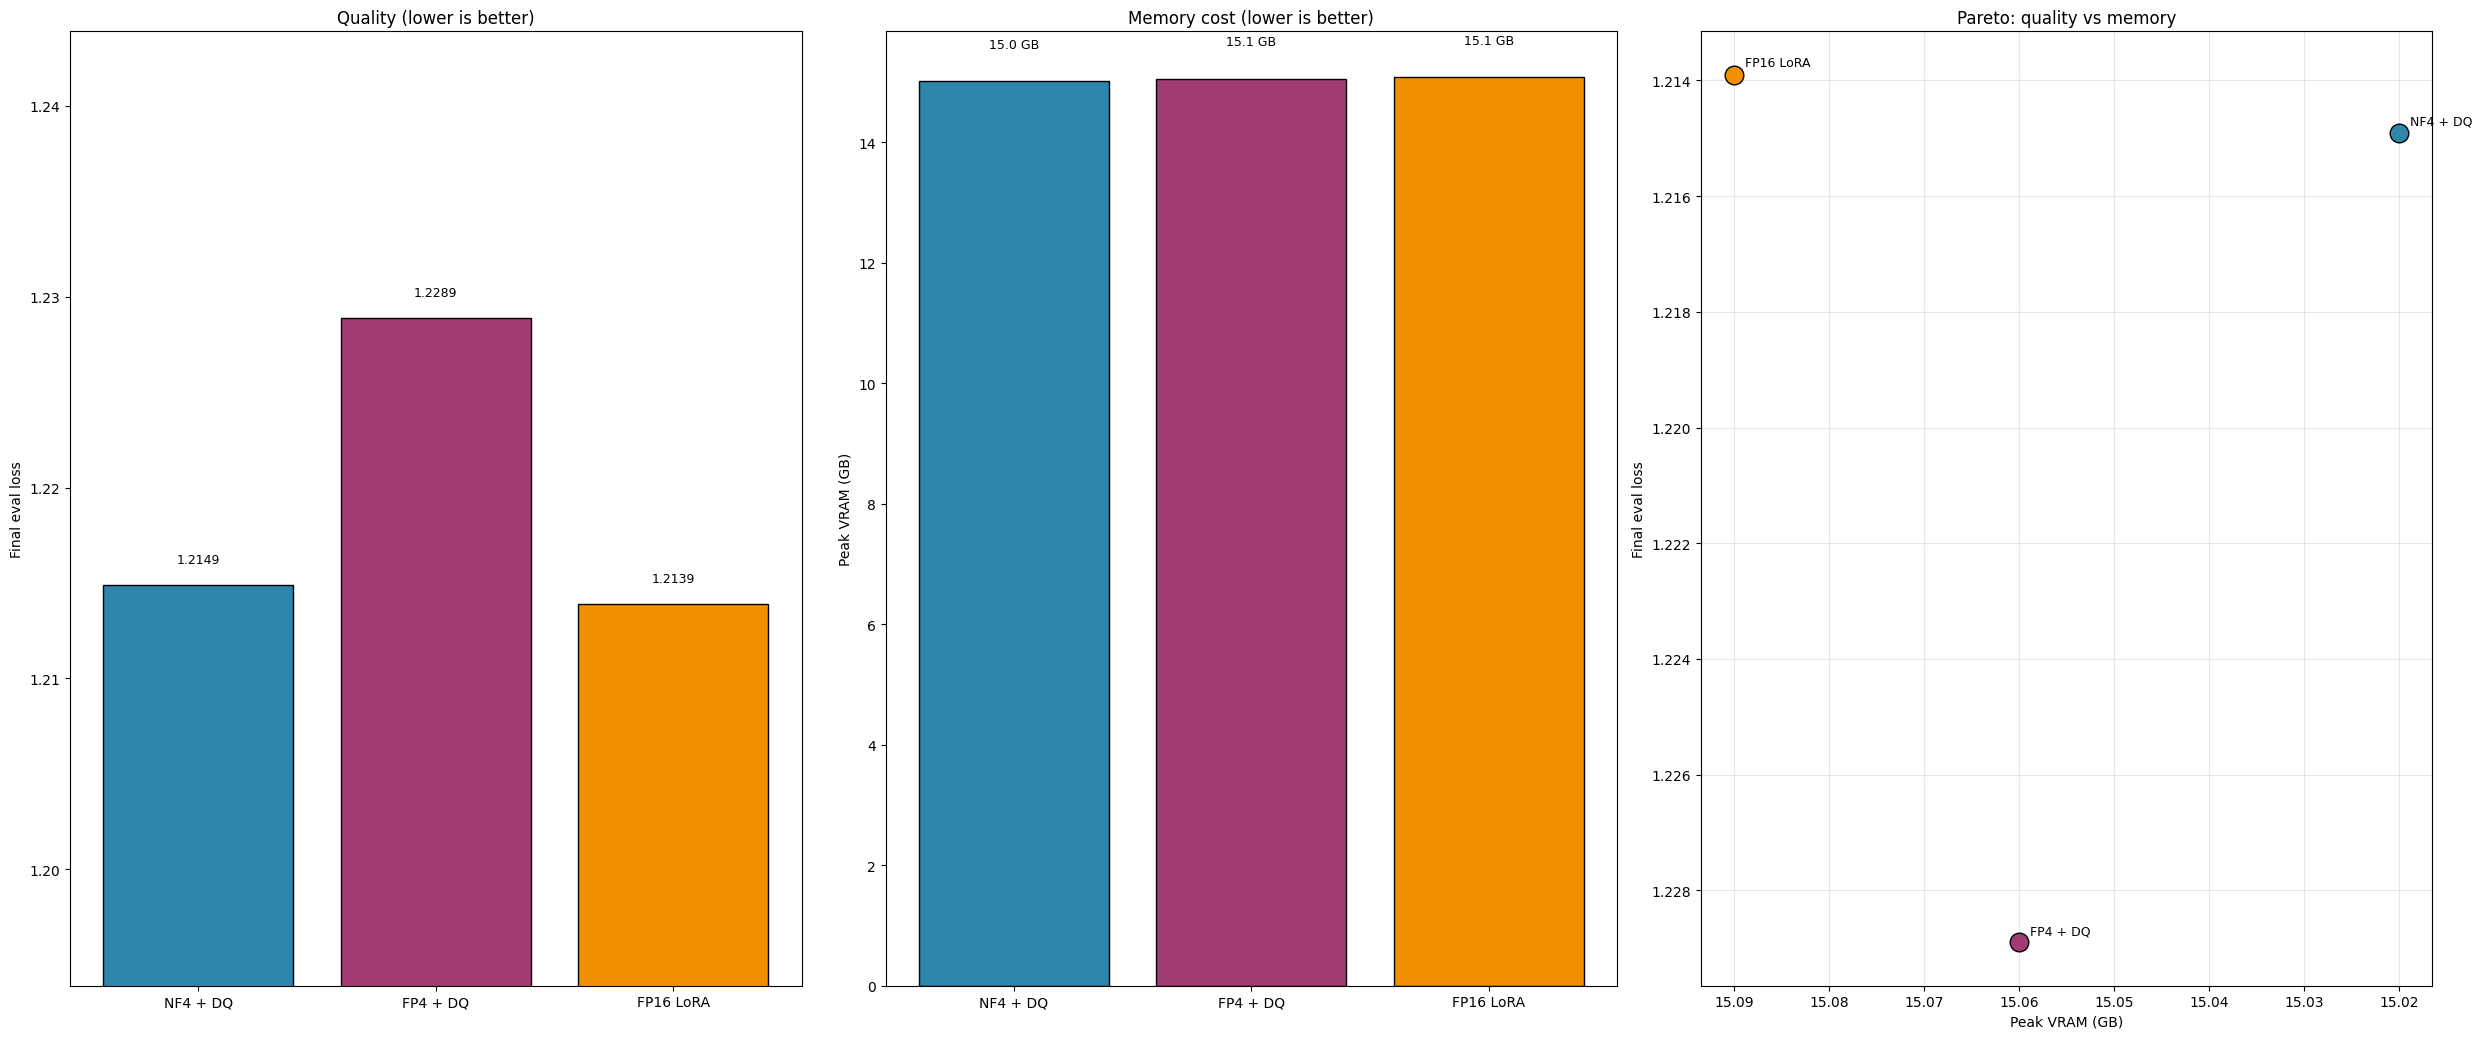

In [37]:
# 7b. Pareto bars:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(25, 10.5))
configs = summary['config'].tolist()
colors  = {'NF4 + DQ': '#2E86AB', 'FP4 + DQ': '#A23B72', 'FP16 LoRA': '#F18F01'}
bar_colors = [colors[c] for c in configs]

# (a) Final eval loss — quality
ax = axes[0]
bars = ax.bar(configs, summary['final_eval'], color=bar_colors, edgecolor='black')
for bar, val in zip(bars, summary['final_eval']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.001, f'{val:.4f}',
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Final eval loss')
ax.set_title('Quality (lower is better)')
ax.set_ylim(min(summary['final_eval']) - 0.02, max(summary['final_eval']) + 0.015)

# (b) Peak VRAM — cost
ax = axes[1]
bars = ax.bar(configs, summary['peak_vram_gb'], color=bar_colors, edgecolor='black')
for bar, val in zip(bars, summary['peak_vram_gb']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f} GB',
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Peak VRAM (GB)')
ax.set_title('Memory cost (lower is better)')

# (c) Pareto — quality vs cost
ax = axes[2]
for _, r in summary.iterrows():
    ax.scatter(r['peak_vram_gb'], r['final_eval'], s=180,
               color=colors[r['config']], edgecolor='black', zorder=3, label=r['config'])
    ax.annotate(r['config'],
                (r['peak_vram_gb'], r['final_eval']),
                xytext=(8, 6), textcoords='offset points', fontsize=9)
ax.set_xlabel('Peak VRAM (GB)')
ax.set_ylabel('Final eval loss')
ax.set_title('Pareto: quality vs memory')
ax.grid(True, alpha=0.3)
ax.invert_yaxis()                       # so "down-and-right is dominated" reads naturally
ax.invert_xaxis()                       # so "lower-left dominates" — Pareto front toward upper-left

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'paper_repro_pareto.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
configs = summary['config'].tolist()
colors  = {'NF4 + DQ': '#2E86AB', 'FP4 + DQ': '#A23B72', 'FP16 LoRA': '#F18F01'}
bar_colors = [colors[c] for c in configs]

# (a) Final eval loss — quality
ax = axes[0]
bars = ax.bar(configs, summary['final_eval'], color=bar_colors, edgecolor='black')
for bar, val in zip(bars, summary['final_eval']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.001, f'{val:.4f}',
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Final eval loss')
ax.set_title('Quality (lower is better)')
ax.set_ylim(min(summary['final_eval']) - 0.02, max(summary['final_eval']) + 0.015)

# (b) Peak VRAM — cost
ax = axes[1]
bars = ax.bar(configs, summary['peak_vram_gb'], color=bar_colors, edgecolor='black')
for bar, val in zip(bars, summary['peak_vram_gb']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f} GB',
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Peak VRAM (GB)')
ax.set_title('Memory cost (lower is better)')

# (c) Pareto — quality vs cost
ax = axes[2]
for _, r in summary.iterrows():
    ax.scatter(r['peak_vram_gb'], r['final_eval'], s=180,
               color=colors[r['config']], edgecolor='black', zorder=3, label=r['config'])
    ax.annotate(r['config'],
                (r['peak_vram_gb'], r['final_eval']),
                xytext=(8, 6), textcoords='offset points', fontsize=9)
ax.set_xlabel('Peak VRAM (GB)')
ax.set_ylabel('Final eval loss')
ax.set_title('Pareto: quality vs memory')
ax.grid(True, alpha=0.3)
ax.invert_yaxis()                       # so "down-and-right is dominated" reads naturally
ax.invert_xaxis()                       # so "lower-left dominates" — Pareto front toward upper-left

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'paper_repro_pareto.png', dpi=150, bbox_inches='tight')
plt.show()
import json
import pandas as pd
from pathlib import Path

ACTIVE_EXPERIMENTS = ['01_nf4_dq_r64_all', '02_fp4_dq_r64_all', '04_fp16_lora_r64_all']

DISPLAY_NAMES = {
    '01_nf4_dq_r64_all':    'NF4 + DQ',
    '02_fp4_dq_r64_all':    'FP4 + DQ',
    '04_fp16_lora_r64_all': 'FP16 LoRA',
}

rows = []
loss_curves = {}   # name -> list of (step, loss)
eval_curves = {}   # name -> list of (step, eval_loss)

for name in ACTIVE_EXPERIMENTS:
    p = RESULTS_DIR / f'{name}_metrics.json'
    if not p.exists():
        print(f'MISSING: {p}')
        continue
    with open(p) as f:
        m = json.load(f)

    train_pts = [(e['step'], e['loss']) for e in m.get('log_history', []) if 'loss' in e and 'step' in e]
    eval_pts  = [(e['step'], e['eval_loss']) for e in m.get('log_history', []) if 'eval_loss' in e]
    loss_curves[name] = train_pts
    eval_curves[name] = eval_pts

    final_train_loss = train_pts[-1][1] if train_pts else None
    final_eval_loss  = eval_pts[-1][1]  if eval_pts  else None
    eval_at_epoch1   = eval_pts[0][1]   if eval_pts  else None

    rows.append({
        'config':        DISPLAY_NAMES[name],
        'wall_min':      round(m.get('wall_clock_s', 0) / 60, 1),
        'peak_vram_gb':  round(m.get('peak_vram_mb', 0) / 1024, 2),
        'final_train':   round(final_train_loss, 4) if final_train_loss else None,
        'eval_ep1':      round(eval_at_epoch1, 4)   if eval_at_epoch1   else None,
        'final_eval':    round(final_eval_loss, 4)  if final_eval_loss  else None,
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
summary.to_csv(RESULTS_DIR / 'paper_repro_summary.csv', index=False)
import json
import pandas as pd

rows = []
for name in EXPERIMENTS:
    p = RESULTS_DIR / f'{name}_metrics.json'
    if not p.exists():
        continue
    with open(p) as f:
        m = json.load(f)
    eval_losses = [e['eval_loss'] for e in m.get('log_history', []) if 'eval_loss' in e]
    final_eval = eval_losses[-1] if eval_losses else None
    rows.append({
        'experiment':   name,
        'wall_min':     round(m.get('wall_clock_s', 0) / 60, 1),
        'peak_vram_gb': round(m.get('peak_vram_mb', 0) / 1024, 2),
        'final_eval':   round(final_eval, 4) if final_eval else None,
        'mmlu':         MMLU_RESULTS.get(name) if 'MMLU_RESULTS' in dir() else None,
    })
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
summary.to_csv(RESULTS_DIR / 'paper_repro_summary.csv', index=False)

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Final eval loss per experiment
ax = axes[0]
ax.bar(summary['experiment'], summary['final_eval'])
ax.set_ylabel('Final eval loss'); ax.set_title('Eval loss across configs')
ax.tick_params(axis='x', rotation=45)

# (b) MMLU vs peak VRAM
ax = axes[1]
if summary['mmlu'].notna().any():
    ax.scatter(summary['peak_vram_gb'], summary['mmlu'])
    for _, r in summary.iterrows():
        if pd.notna(r['mmlu']):
            ax.annotate(r['experiment'], (r['peak_vram_gb'], r['mmlu']), fontsize=8)
    ax.set_xlabel('Peak VRAM (GB)'); ax.set_ylabel('MMLU accuracy'); ax.set_title('Quality vs memory Pareto')
else:
    ax.text(0.5, 0.5, 'No MMLU results yet', ha='center', va='center')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'paper_repro_pareto.png', dpi=120)
plt.show()

In [ ]:
# Loss curves overlaid (training loss only — eval loss is sparse)
fig, ax = plt.subplots(figsize=(10, 6))
for name in EXPERIMENTS:
    p = RESULTS_DIR / f'{name}_metrics.json'
    if not p.exists():
        continue
    with open(p) as f:
        m = json.load(f)
    pts = [(e['step'], e['loss']) for e in m.get('log_history', []) if 'loss' in e and 'step' in e]
    if pts:
        xs, ys = zip(*pts)
        ax.plot(xs, ys, label=name, alpha=0.85)
ax.set_xlabel('Step'); ax.set_ylabel('Train loss'); ax.set_title('Training loss curves')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'paper_repro_loss_curves.png', dpi=120)
plt.show()

## 8. Reading the results

Cross-check against the paper:

| Comparison | What the paper says | What you observed |
|------------|---------------------|--------------------|
| NF4 vs FP4 (Exp 1 vs 2) | NF4 wins by ~0.3-0.7 pt | _fill in_ |
| DQ free? (Exp 1 vs 3)   | Equal quality, ~0.4 bits/param savings | _fill in_ |
| QLoRA vs FP16 (1 vs 4)  | Within ~1 pt MMLU, ~½ VRAM | _fill in_ |
| Rank robustness (1, 5, 6) | Within noise above r=8 | _fill in_ |
| All-linear vs q+v (1 vs 7) | All-linear wins ~1-2 pt MMLU | _fill in_ |

Caveats specific to our setup:
- Single seed — small effects (NF4-vs-FP4, DQ ablation) are within seed noise. Add a second seed if a comparison comes out wrong.
- 20k Alpaca subset, not the full 52k or OASST1 used in the paper. Absolute numbers won't match the paper; relative ordering should.
- We do not run Vicuna pairwise GPT-4 eval — too slow and noisy at this scale.